# Практическая работа 6 (Тест)

**Тема**: Введение в статистический анализ данных

### Настройка окружения

In [1]:
import pandas as pd

## Часть 1

Для успешного прохождения теста вам потребуется воспользоваться [данными](./StarWars.csv) по серии фильмов «Звездные войны», самостоятельно загрузив их в Python.

*Описание данных*

- **respondentID** — идентификационный номер респондента;
- **seen** — ответ на вопрос, видел ли респондент хотя бы один фильм из серии «Звездных войн» (да/нет);
- **fan** — ответ на вопрос, считает ли респондент себя фанатом серии фильмов (да/нет);
- **gender** — пол респондента (М/Ж);
- **age_group** — возрастная группа, к которой принадлежит респондент (18-29, 30-44, 45-60, > 60);
- **income** — доход респондента в долларах США (0 - 24.999, 25.000 - 49.999, 50.000 - 99.999, 100.000 - 149.999, 150.000+);
- **loc** — регион проживания респондента (в США);
- **yoda** — отношение респондента к персонажу серии (Йоде);
- **princess_leia_organa** — отношение респондента к персонажу серии (принцессе Лее Органе).

In [2]:
survey = pd.read_csv("StarWars.csv", sep=";")
survey.head()

,respondentID,seen,fan,gender,age_group,income,loc,yoda,princess_leia_organa
0,3292879998,да,да,М,18-29,NaN,Южно-Атлантический,очень нравится,очень нравится
1,3292879538,нет,NaN,М,18-29,0 - 24.999,Юго-Западный центральный,NaN,NaN
2,3292765271,да,нет,М,18-29,0 - 24.999,Северо-Западный центральный,не знаю такого персонажа,нравится
3,3292763116,да,да,М,18-29,100.000 - 149.999,Северо-Западный центральный,очень нравится,очень нравится
4,3292731220,да,да,М,18-29,100.000 - 149.999,Северо-Западный центральный,нравится,нравится


### Вопрос 1

К какой шкале относится переменная `princess_leia_organa`?

1. Интервальная
2. Порядковая
3. Номинальная
4. Шкала отношений

In [3]:
survey["princess_leia_organa"].unique()

<StringArray>
[          'очень нравится',                        nan,
                 'нравится',              'не нравится',
      'отношусь нейтрально',        'очень не нравится',
 'не знаю такого персонажа']
Length: 7, dtype: str

*Ответ*: Порядковая

### Вопрос 2

Сколько респондентов не ответили на вопрос о своей возрастной группе?

In [4]:
survey["age_group"].isnull().sum()

np.int64(140)

### Вопрос 3

Данные каких столбцов можно упорядочить?

- [ ] 1. age_group
- [ ] 2. loc
- [ ] 3. gender
- [ ] 4. income

*Ответ*: `age_group`, `income` 

### Вопрос 4

Укажите, верно ли следующее утверждение: все мужчины возрастной категории 45-60 лет входящие в категорию с наивысшим доходом и являющиеся фанатами серии фильмов, проживают в одном регионе.

In [5]:
survey[
  (survey["gender"] == "М")
  & (survey["age_group"] == "45-60")
  & (survey["income"] == "150.000+")
  & (survey["fan"] == "да")
]["loc"].nunique() == 1

False

### Вопрос 5
Мужчины 18-29 лет, которые не являются фанатами серии, чаще всего проживают в ... регионе.

In [6]:
survey[
  (survey.gender == "М")
  & (survey["age_group"] == "18-29")
  & (survey.fan == "нет")
]["loc"].value_counts().idxmax()

'Тихоокеанский'

### Вопрос 6
Какой регион проживания реже всего встречается в данных?

In [7]:
survey["loc"].value_counts().idxmin()

'Юго-Восточный центральный'

### Вопрос 7

Сколько респондентов не видели ни одного фильма серии, но считают себя ее фанатами?

In [8]:
# yoda_and_leia_fans = survey[
#     (survey.yoda == "очень нравится")
#     & (survey["princess_leia_organa"] == "очень нравится")
# ]

# len(yoda_and_leia_fans)

len(survey[
  (survey["seen"] == "нет")
  & (survey["fan"] == "да")
])

0

### Вопрос 8

Скольким респондентам из Южно-Атлантического региона очень нравится принцесса Лея Органа?

In [9]:
len(survey[
  (survey["loc"] == "Южно-Атлантический")
  & (survey["princess_leia_organa"] == "очень нравится")
])

93

### Вопрос 9

Посмотрите на мужчин, проживающих в горном районе. В ответ запишите ID респондента, входящего в категорию с наивысшим доходом при заданных условиях.

In [10]:
survey[
  (survey["gender"] == "М")
  & (survey["loc"] == "Горный")
  & (survey["income"] == "150.000+")
].iloc[0]["respondentID"]

np.int64(3291077381)

### Вопрос 10

Верно ли следующее утверждение: фанатов серии фильмов в возрастной категории 45-60 меньше, чем не-фанатов в возрастной категории 18-29.

В ответе укажите абсолютное значение разницы между числом фанатов и не-фанатов при заданных условиях.

In [11]:
abs(
  len(survey[
    (survey["age_group"] == "45-60")
    & (survey["fan"] == "да")
  ]) - len(survey[
    (survey["age_group"] == "18-29")
    & (survey["fan"] == "нет")
  ])
)

98

### Вопрос 11

Сколько процентов (от общего числа респондентов) являются фанатами серии фильмов, проживают в Новой Англии и имеют доход 0 - 24.999 долларов?

В ответ запишите число (процент от 0 до 100), округлите до целого.

---

Сколько процентов (от общего числа респондентов) являются фанатами серии фильмов, проживают в Новой Англии и имеют доход 0 - 24.999 долларов?

В ответ запишите число (процент от 0 до 100), округлите до целого.

In [12]:
round(
  len(survey[
    (survey["fan"] == "да")
    & (survey["loc"] == "Новая Англия")
    & (survey["income"] == "0 - 24.999")
  ]) / len(survey) * 100
)

1

## Часть 2

Для успешного прохождения теста вам потребуется воспользоваться [данными](./MarvelComicCharacters.csv) персонажей вселенной Marvel, самостоятельно загрузив их в Python.

**Описание данных**
- name — оригинальное имя персонажа вселенной Marvel
- align — принадлежность персонажа к доброй/злой/нейтральной стороне
- eye — описание глаз персонажа
- hair — описание волос персонажа
- sex — пол персонажа
- appearances — количество появлений персонажа
- first_appearance — год первого появления персонажа

In [13]:
characters = pd.read_csv("MarvelComicCharacters.csv", sep=";")
characters.head()

,name,align,eye,hair,sex,appearances,first_appearance
0,Spider-Man (Peter Parker),Добрый персонаж,Карие глаза,Каштановые волосы,Мужской персонаж,4043.0,1962.0
1,Captain America (Steven Rogers),Добрый персонаж,Голубые глаза,Белые волосы,Мужской персонаж,3360.0,1941.0
2,"Wolverine (James \""Logan\"" Howlett)",Нейтральный персонаж,Голубые глаза,Черные волосы,Мужской персонаж,3061.0,1974.0
3,"Iron Man (Anthony \""Tony\"" Stark)",Добрый персонаж,Голубые глаза,Черные волосы,Мужской персонаж,2961.0,1963.0
4,Thor (Thor Odinson),Добрый персонаж,Голубые глаза,Русые волосы,Мужской персонаж,2258.0,1950.0


### Вопрос 1

Что не может представлять собой генеральную совокупность?

1. Россияне
2. Школьники Красноярска
3. Нет верного ответа
4. Мужчины в возрастной группе 25-30 лет

*Ответ*: Нет верного ответа

### Вопрос 2

Укажите, верно ли следующее утверждение: переменную `name` можно изобразить на интерпретируемом графике.

*Ответ*: Неверно

### Вопрос 3

Какое значение находится в колонке `appearances` для доброго персонажа с пурпурными глазами?

In [14]:
characters[
  (characters["align"] == "Добрый персонаж")
  & (characters["eye"] == "Пурпурные глаза")
].iloc[0]["appearances"]

np.float64(21.0)

### Вопрос 4

Заполните пропущенное значение во фрагменте частотной таблицы по переменной `eye`.

| Голубые глаза | Зеленые глаза | Белые глаза |
| ------------- | ------------- | ----------- |
| 1926          | ...           | 400         |

In [15]:
characters["eye"].value_counts()["Зеленые глаза"]

np.int64(613)

### Вопрос 5

Постройте частотную таблицу по переменной `hair` для персонажей женского пола с карими глазами. У скольких из них русые волосы?

In [16]:
characters[
  (characters["sex"] == "Женский персонаж")
  & (characters["eye"] == "Карие глаза")
]["hair"].value_counts()["Русые волосы"]

np.int64(4)

### Вопрос 6

Какой тип графика из перечисленных наиболее удобен для описания распределения переменной `eye`?

1. График построить нельзя
2. Столбчатая диаграмма
3. Гистограмма
4. Линейный график

In [17]:
characters["eye"].value_counts()

eye
Голубые глаза            1962
Темно-карие глаза        1924
Зеленые глаза             613
Черные глаза              555
Красные глаза             508
Белые глаза               400
Желтые глаза              256
Серые глаза                95
Карие глаза                76
Разноцветные глаза         49
Фиолетовые глаза           31
Оранжевые глаза            25
Розовые глаза              21
Один глаз                  21
Золотые глаза              14
Серебристые глаза          12
Лиловые глаза              11
Янтарные глаза             10
Много глаз                  7
Нет глаз                    7
Желтые глазные яблоки       6
Черные глазные яблоки       3
Пурпурные глаза             2
Фасеточные глаза            1
Name: count, dtype: int64

*Ответ*: Столбчатая диаграмма

### Вопрос 7

Меньше всего персонажей в первый раз появилось в ... году.

In [18]:
characters["first_appearance"].value_counts().idxmin()

np.float64(1958.0)

### Вопрос 8

Сколько процентов (от общего числа персонажей) составляют женские персонажи, которые появлялись больше 10 раз?

В ответ запишите число (процент от 0 до 100), округлите до целого.

In [19]:
round(
  len(characters[
    (characters["sex"] == "Женский персонаж")
    & (characters["appearances"] > 10)
  ]) / len(characters) * 100
)

6

### Вопрос 9

Были выбраны 5 самых часто встречающихся цветов волос персонажей. Выберите столбчатую диаграмму, которая была построена только по этим данным.

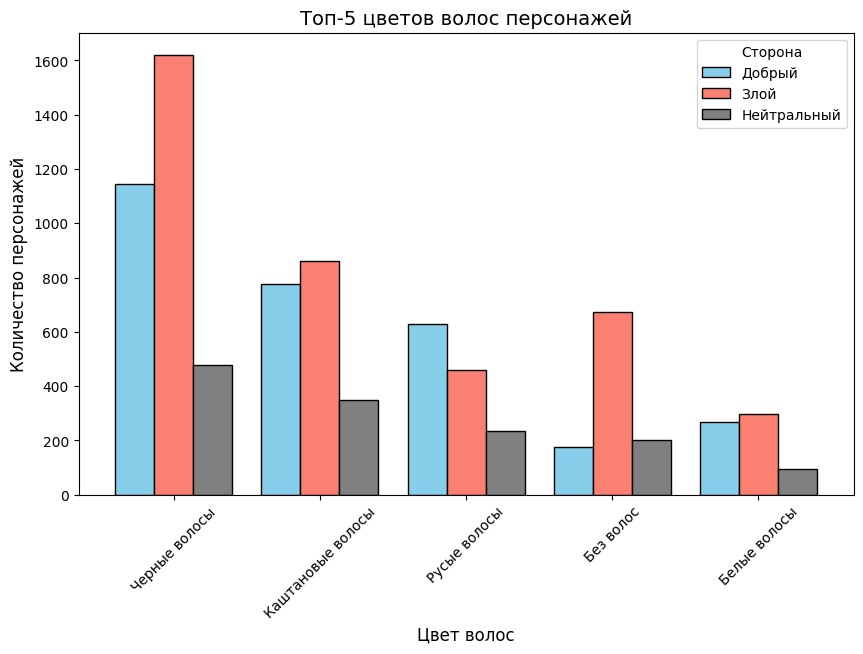

In [20]:
import matplotlib.pyplot as plt

frequent_hair = characters["hair"].value_counts().head(5)
hair_align_counts = characters.groupby(["hair", "align"]).size().unstack(fill_value=0)
top_hair = frequent_hair.index
hair_align_counts = hair_align_counts.loc[top_hair]
ax = hair_align_counts.plot(
  kind="bar",
  figsize=(10, 6),
  width=0.8,
  color=["skyblue", "salmon", "gray"],
  edgecolor="black",
)

plt.title("Топ-5 цветов волос персонажей", fontsize=14)
plt.xlabel("Цвет волос", fontsize=12)
plt.ylabel("Количество персонажей", fontsize=12)

plt.xticks(rotation=45)

plt.legend(title="Сторона", labels=["Добрый", "Злой", "Нейтральный"])

plt.show()

In [21]:
import subprocess
subprocess.run(["jupyter", "nbconvert", "--to", "html", __vsc_ipynb_file__])

[NbConvertApp] Converting notebook /Users/efim/dev/university-6sem-data-analysis/topic6/practice6/practice6.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 391178 bytes to /Users/efim/dev/university-6sem-data-analysis/topic6/practice6/practice6.html


CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', '/Users/efim/dev/university-6sem-data-analysis/topic6/practice6/practice6.ipynb'], returncode=0)